In [1]:
from langgraph.graph import  StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict , Literal 
from pydantic import BaseModel , Field
from langchain_core.messages import SystemMessage , HumanMessage

In [2]:
model = ChatOpenAI(model = 'gpt-4o-mini')

In [3]:
class TweetState(TypedDict):
    tweet : str
    topic : str
    evaluation : Literal['approved', 'need_improvement']
    iteration : int 
    max_iteration : int 
    feedback : str

In [4]:
class Evaluation_Schema(BaseModel):
    evaluation : Literal['approved','need_improvement'] = Field(description ='Evaluation of the tweet')
    feedback : str = Field(description = 'feedback for the tweet')

In [5]:
structured_model = model.with_structured_output(Evaluation_Schema)

In [6]:
graph = StateGraph(TweetState)

In [7]:
def tweet_generator(state: TweetState):
    #prompt
    message = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer"),
        HumanMessage(content = f"""Write a short, original, and hilarious tweet on the topic: "{state['topic']}"

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english""")
    ]
    #invoke model 
    response = model.invoke(message).content

    #return 
    return {'tweet': response}

In [8]:
def tweet_evaluation(state: TweetState):
    message = [
        SystemMessage(content = "You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content = f""" Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_model.invoke(message)

    return {'evaluation': response.evaluation , 'feedback':response.feedback}

In [9]:
def tweet_optimizer(state: TweetState):
    message = [
        SystemMessage(content='You punch up tweets for virality and humor based on given feedback.'),
        HumanMessage(content= f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}" \n
    
    Topic : "{state['topic']}"
    Original Tweet : "{state['tweet']}"
    
    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
    ]
    
    response = model.invoke(message).content
    iteration = state['iteration'] + 1
    
    return{'tweet' : response ,'iteration' : iteration}
    

In [10]:
graph.add_node('tweet_generator' , tweet_generator)
graph.add_node('tweet_evaluation', tweet_evaluation)
graph.add_node('tweet_optimizer', tweet_optimizer)

In [11]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'need_improvement'

In [12]:
graph.add_edge(START, 'tweet_generator')
graph.add_edge('tweet_generator', 'tweet_evaluation')

graph.add_conditional_edges('tweet_evaluation', route_evaluation ,{'approved': END , 'need_improvement' : 'tweet_optimizer'})
graph.add_edge('tweet_optimizer' , 'tweet_evaluation')

In [13]:
workflow = graph.compile()

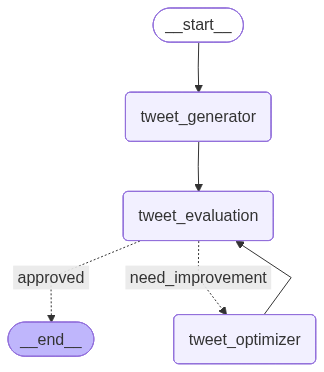

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())